# Threesome: loc vs disp vs exact conserved current ($G_t$, $G_s$) — deterministic, lattice prop, $L=1,2$

All **insertion-diagonal** now (same observable, reproduces Eqs. 4.31/4.28):

- **loc** (`jj_local_deter`, `corr_deter_local_L*`): on-site bare $\sigma^a$. $G_t=$`s3`, $G_s=$`s1`+`s2`.
- **disp** (`jj_disp_deter`, `corr_deter_disp_L*`): displaced Wilson link $W^{wz}/\kappa$ (ultralocal
  part of K). sp only, key `sp`.
- **exact** (`jj_exact_diag_deter`, `corr_deter_exact1_L*`): full overlap conserved current $K$
  (with the GW resolvent dressing), SAME weights/kernel base as disp, insertion-diagonal. Keys `tp`,`sp`.

Compare: **tp** = loc vs exact ; **sp** = loc vs disp vs exact.  Each is a different discretization, so
they differ by an O(1) renormalization (matched at one separation here).  **Headline = the relative
SIGN** (the matching constant's sign): does exact sp agree with disp/loc now that all three are
insertion-diagonal?  (Previously the double-sum exact sp came out with the opposite sign.)

In [5]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ESN  = dir1 + 'data_free_vmRe0.000000vmIm0.000000/'
at_cft = 0.2
Nt_cft = 128
Delta_cft = 2.0
tag = ''   # '' = lattice prop ; 'cont_' = continuum prop

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

def load_Vpp(corrdir, proj, origin='t0_0', k=0):
    path = ESN + corrdir + '/corr.' + str(k) + '.h5'
    with h5py.File(path, 'r') as f:
        key = 'h0/' + origin + '/' + proj + '/Vpp'
        return f[key+'/real'][()] + 1j*f[key+'/imag'][()]

def loc_Gt(L):  cd='corr_deter_local_%sL%d'%(tag,L); return load_Vpp(cd,'s3').real
def loc_Gs(L):  cd='corr_deter_local_%sL%d'%(tag,L); return (load_Vpp(cd,'s1')+load_Vpp(cd,'s2')).real
def disp_Gs(L): return load_Vpp('corr_deter_disp_%sL%d'%(tag,L),'sp').real
def ex_Gt(L):   return load_Vpp('corr_deter_exact1_%sL%d'%(tag,L),'tp').real
def ex_Gs(L):   return load_Vpp('corr_deter_exact1_%sL%d'%(tag,L),'sp').real

tp L=1: exact/loc match const =  0.6778  (sign +1)
exact tp L=2 missing


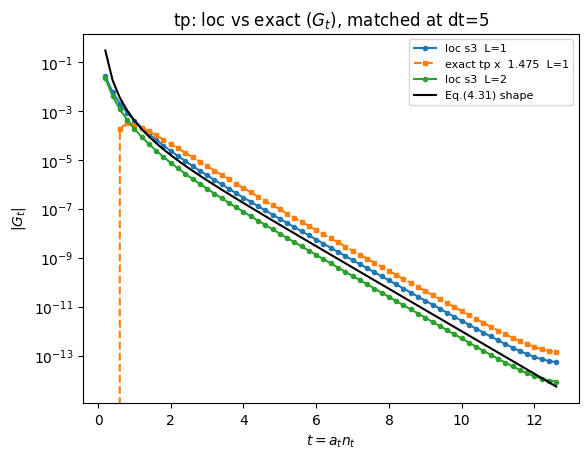

In [6]:
# tp ( = G_t, Eq.4.31): loc s3 vs exact tp, L=1,2.  Each matched to loc at dt=ref; |.| on log scale.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2]:
    gl = loc_Gt(L)
    plt.plot(t, -gl[dt], 'o-', ms=3, label='loc s3  L=%d' % L)
    try:
        ge = ex_Gt(L); 
        c = gl[ref]/ge[ref]
        print('tp L=%d: exact/loc match const = % .4f  (sign %+d)' % (L, 1.0/c, int(np.sign(c))))
        plt.plot(t, -ge[dt], 's--', ms=3, label='exact tp x % .3f  L=%d' % (c, L))
    except (OSError, KeyError):
        print('exact tp L=%d missing' % L)
A = loc_Gt(1)[ref] / cft_shape(t[ref-1])
plt.plot(t, -A*cft_shape(t), 'k-', label='Eq.(4.31) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_t|$')
plt.title('tp: loc vs exact ($G_t$), matched at dt=%d' % ref); plt.legend(fontsize=8)
plt.savefig('comp_threesome_tp.pdf', bbox_inches='tight')

sp L=1: disp/loc  match const =  0.5598  (sign +1)
sp L=1: exact/loc match const =  0.0192  (sign +1)


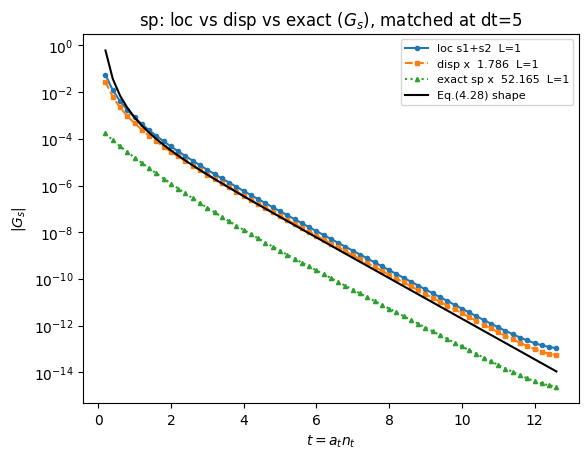

In [7]:
# sp ( = G_s, Eq.4.28): loc s1+s2 vs disp vs exact sp, L=1,2.  Matched to loc at dt=ref.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1]:
    gl = loc_Gs(L)
    plt.plot(t, gl[dt], 'o-', ms=3, label='loc s1+s2  L=%d' % L)
    try:
        gd = disp_Gs(L); cd = gl[ref]/gd[ref]
        print('sp L=%d: disp/loc  match const = % .4f  (sign %+d)' % (L, 1.0/cd, int(np.sign(cd))))
        plt.plot(t, gd[dt], 's--', ms=3, label='disp x % .3f  L=%d' % (cd, L))
    except (OSError, KeyError):
        print('disp sp L=%d missing' % L)
    try:
        ge = ex_Gs(L); ce = gl[ref]/ge[ref]
        print('sp L=%d: exact/loc match const = % .4f  (sign %+d)' % (L, 1.0/ce, int(np.sign(ce))))
        plt.plot(t, ge[dt], '^:', ms=3, label='exact sp x % .3f  L=%d' % (ce, L))
    except (OSError, KeyError):
        print('exact sp L=%d missing' % L)
A = loc_Gs(1)[ref] / cft_shape(t[ref-1])
plt.plot(t, A*cft_shape(t), 'k-', label='Eq.(4.28) shape')
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_s|$')
plt.title('sp: loc vs disp vs exact ($G_s$), matched at dt=%d' % ref); plt.legend(fontsize=8)
plt.savefig('comp_threesome_sp.pdf', bbox_inches='tight')

In [8]:
# SIGN table (the headline): sign of each correlator at dt=5 relative to loc.  Same sign => agree.
print('%-4s %-12s %-12s %-12s %-12s' % ('L', 'loc_Gt(s3)', 'exact_tp', 'loc_Gs(s1+s2)', 'disp_sp / exact_sp'))
for L in [1, 2]:
    row = [L]
    def g(f):
        try: return '% .3e' % f(L)[5]
        except (OSError, KeyError): return '   --      '
    print('L=%d  Gt: loc=%s  exact=%s | Gs: loc=%s  disp=%s  exact=%s' % (
        L, g(loc_Gt), g(ex_Gt), g(loc_Gs), g(disp_Gs), g(ex_Gs)))
print('\n(Headline: do exact_sp and disp_sp share loc_Gs sign?  If exact_sp flips vs disp/loc, that is')
print(' the GW/resolvent dressing; if all agree, the old +/- puzzle was the double-sum (q=0) artifact.)')

L    loc_Gt(s3)   exact_tp     loc_Gs(s1+s2) disp_sp / exact_sp
L=1  Gt: loc=-4.130e-04  exact=-2.799e-04 | Gs: loc= 8.260e-04  disp= 4.624e-04  exact= 1.583e-05
L=2  Gt: loc=-1.896e-04  exact=   --       | Gs: loc= 3.792e-04  disp= 2.118e-04  exact=   --      

(Headline: do exact_sp and disp_sp share loc_Gs sign?  If exact_sp flips vs disp/loc, that is
 the GW/resolvent dressing; if all agree, the old +/- puzzle was the double-sum (q=0) artifact.)


L      loc Gs/Gt      disp sp/loc_Gt exact Gs/Gt   
L=1    -2.0000        -1.1196        -0.0566       
L=2    -2.0000        -1.1172           --         

(loc & exact ratios are Z-independent; loc should be closest to -2 already.  disp/loc_Gt
 still carries the disp-vs-loc relative renormalization, so read its SHAPE/sign, not the value.)


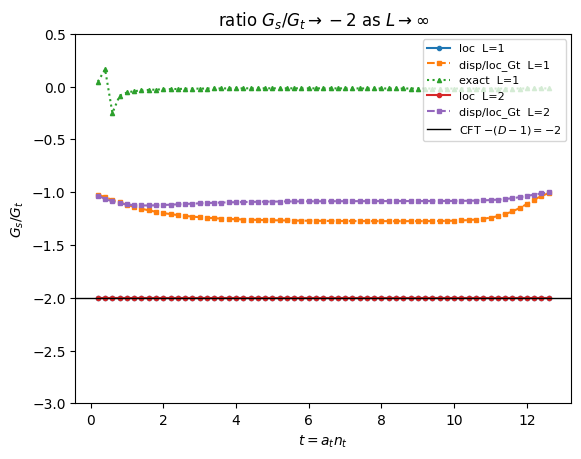

In [9]:
# RATIO G_s/G_t for loc, disp, exact at L=1,2.  CFT: G_s/G_t = -(D-1) = -2 at every separation,
# and the Z-factor cancels within a discretization that supplies BOTH channels (loc, exact).
# disp has only an sp channel, so its ratio uses loc's tp denominator (disp_sp / loc_Gt) and is
# therefore meaningful only up to the disp/loc relative renormalization -- labelled accordingly.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
print('%-6s %-14s %-14s %-14s' % ('L', 'loc Gs/Gt', 'disp sp/loc_Gt', 'exact Gs/Gt'))
for L in [1, 2]:
    # loc: own sp/tp (Z cancels)
    rl = loc_Gs(L) / loc_Gt(L)
    plt.plot(t, rl[dt], 'o-', ms=3, label='loc  L=%d' % L)
    sl = '% .4f' % rl[ref]
    # disp: sp / loc tp (relative Z not cancelled)
    try:
        rd = disp_Gs(L) / loc_Gt(L)
        plt.plot(t, rd[dt], 's--', ms=3, label='disp/loc_Gt  L=%d' % L)
        sd = '% .4f' % rd[ref]
    except (OSError, KeyError):
        sd = '   --   '
    # exact: own sp/tp (Z cancels)
    try:
        re = ex_Gs(L) / ex_Gt(L)
        plt.plot(t, re[dt], '^:', ms=3, label='exact  L=%d' % L)
        se = '% .4f' % re[ref]
    except (OSError, KeyError):
        se = '   --   '
    print('L=%-4d %-14s %-14s %-14s' % (L, sl, sd, se))
plt.axhline(-2.0, color='k', ls='-', lw=1, label=r'CFT $-(D-1)=-2$')
plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$G_s/G_t$')
plt.ylim(-3.0, 0.5)
plt.title(r'ratio $G_s/G_t \to -2$ as $L\to\infty$'); plt.legend(fontsize=8)
plt.savefig('comp_threesome_ratio.pdf', bbox_inches='tight')
print('\n(loc & exact ratios are Z-independent; loc should be closest to -2 already.  disp/loc_Gt')
print(' still carries the disp-vs-loc relative renormalization, so read its SHAPE/sign, not the value.)')